In [1]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import joblib
import os
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("./data/train_clean.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Name                      100000 non-null  object 
 1   Age                       100000 non-null  float64
 2   SSN                       100000 non-null  object 
 3   Occupation                100000 non-null  object 
 4   Annual_Income             100000 non-null  float64
 5   Monthly_Inhand_Salary     100000 non-null  float64
 6   Num_Bank_Accounts         100000 non-null  float64
 7   Num_Credit_Card           100000 non-null  float64
 8   Interest_Rate             100000 non-null  int64  
 9   Num_of_Loan               100000 non-null  float64
 10  Delay_from_due_date       100000 non-null  float64
 11  Num_of_Delayed_Payment    100000 non-null  float64
 12  Changed_Credit_Limit      100000 non-null  object 
 13  Num_Credit_Inquiries      100000 non-null  fl

## 24. Separation features et target

In [4]:
X = df.drop("Credit_Score", axis=1)
y = df["Credit_Score"]

## 25. Encodage de y avec LabelEncoder

In [5]:
le = LabelEncoder()
y = le.fit_transform(y)
print("Classes :", le.classes_)

Classes : ['Good' 'Poor' 'Standard']


## 26. Encodage des variables categorielles de X

### On identifie d'abord les colonnes de type "object" qui ont le plus de valeurs unique pour supprimer afin d'optimiser la RAM
### De plus on supprime les oins pertinentes pour la cible reperable avec le Heatap

In [6]:
for col in X.select_dtypes(include="object").columns:
    print(col, X[col].nunique())

Name 10139
SSN 12501
Occupation 16
Changed_Credit_Limit 4384
Credit_Mix 4
Payment_of_Min_Amount 3
Payment_Behaviour 7


In [7]:
X = X.drop( columns=["Name", "SSN","Monthly_Balance","Interest_Rate","Total_EMI_per_month","Amount_invested_monthly","Annual_Income",
                    "Credit_Utilization_Ratio"]) #On supprime les variables Name et SSN

### On encode ensuite les variables categorielle restante de X

In [8]:
X = pd.get_dummies(X, drop_first=True)

## 27. Decoupage Train/ Test

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Dimensions X_train : {X_train.shape}")
print(f"Dimensions X_test : {X_test.shape}")
print(f"Dimensions y_train : {y_train.shape}")
print(f"Dimensions y_test : {y_test.shape}")

Dimensions X_train : (80000, 4419)
Dimensions X_test : (20000, 4419)
Dimensions y_train : (80000,)
Dimensions y_test : (20000,)


## 28. Standardisation

In [10]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 29. Entrainement avec la Regression logistique

In [11]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

## 30. Evaluation

In [12]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy :", accuracy)

print("\nClassification Report :")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("\nMatrice de confusion :")
print(cm)



Accuracy : 0.6608

Classification Report :
              precision    recall  f1-score   support

           0       0.57      0.56      0.57      3566
           1       0.67      0.55      0.60      5799
           2       0.68      0.75      0.72     10635

    accuracy                           0.66     20000
   macro avg       0.64      0.62      0.63     20000
weighted avg       0.66      0.66      0.66     20000


Matrice de confusion :
[[2007  137 1422]
 [ 330 3202 2267]
 [1177 1451 8007]]


## 31. Sauvegarder la matrice de confusion

<Axes: >

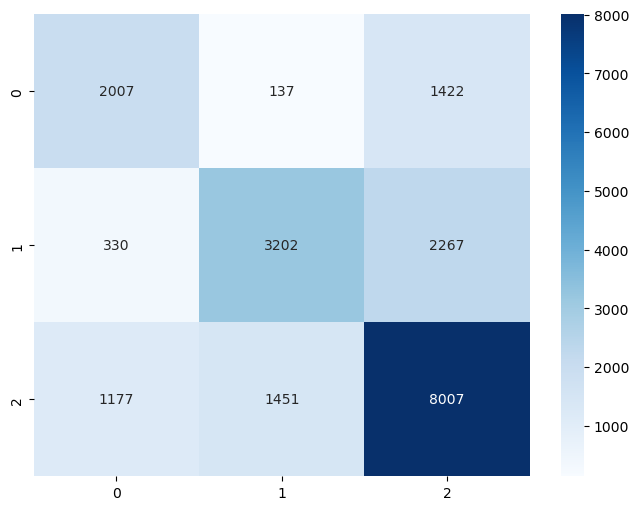

In [13]:
os.makedirs("figures", exist_ok=True)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

## 32. Sauvegarder uniquement le modèle

In [14]:
os.makedirs("models", exist_ok=True)

joblib.dump(
    model,
    "models/credit_model.pkl"
)

print("\nModèle sauvegardé avec succès.")


Modèle sauvegardé avec succès.
